# Radar Cross Section

This code is being developed to eventually plot surrounding radar data given the location of 
an in-situ research aircraft.

In [1]:
import pyart
import xarray as xr
import os
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# Flight track over radar data plot
citation_nav = pd.read_csv('flight_data/2011-05-20_CITATION.dat', sep = ',', header = None)
cit_time = citation_nav.iloc[:, 1]
cit_lat = citation_nav.iloc[:, 2]
cit_lon = citation_nav.iloc[:, 3]

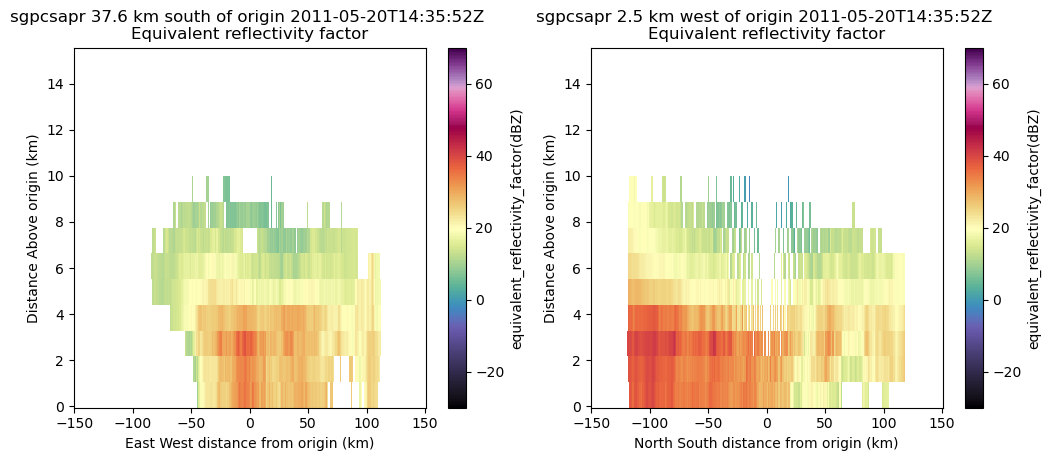

In [3]:
# Read in radar data file
filename = 'sgpcsaprsurcmacI7.c0.20110520.143552.nc.v0'
data = pyart.io.read('C-SAPR_May_20_2011/' + filename)

# Convert file to cartesian coordinates

# Define grid limits 
z_grid_limits = (500., 15000.)
y_grid_limits = (-150000.,150000.)
x_grid_limits = (-150000.,150000.)

grid_resolution = 1000

def compute_number_of_points(extent, resolution):
    return int((extent[1] - extent[0])/resolution)

z_grid_points = compute_number_of_points(z_grid_limits, grid_resolution)
x_grid_points = compute_number_of_points(x_grid_limits, grid_resolution)
y_grid_points = compute_number_of_points(y_grid_limits, grid_resolution)

grid = pyart.map.grid_from_radars(data,
                                  grid_shape=(z_grid_points,
                                              y_grid_points,
                                              x_grid_points),
                                  grid_limits=(z_grid_limits,
                                               y_grid_limits,
                                               x_grid_limits),
                                 )


fig = plt.figure(figsize = (11,9))
display = pyart.graph.GridMapDisplay(grid)
time_step = 150
# Horizontal reflectivity
ax = fig.add_axes([0.53, 0.50, 0.40, 0.40])
display.plot_longitude_slice('corrected_reflectivity_horizontal',
                  ax = ax,
                  lon=cit_lon[time_step],
                  vmin=-30,
                  vmax=70,
                  cmap='ChaseSpectral')


# Vertical cross section reflectivity
ax1 = fig.add_axes([0.06, 0.50, 0.40, 0.40])
display.plot_latitude_slice('corrected_reflectivity_horizontal',
                            ax = ax1,
                            lat=cit_lat[time_step],
                            vmin=-30,
                            vmax=70,
                            cmap='ChaseSpectral')

#plt.savefig('Cross_Section_Radar2.png')

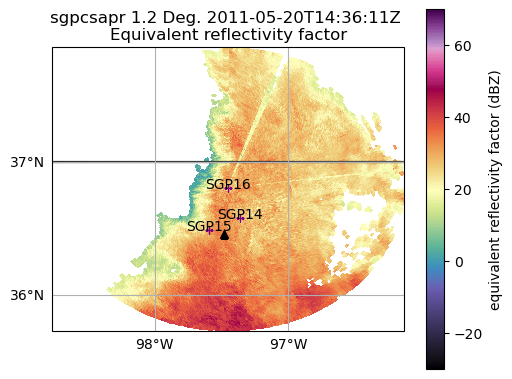

In [4]:
display = pyart.graph.RadarMapDisplay(data)

projection = ccrs.PlateCarree()

fig = plt.figure(figsize = (11,9))

ax = fig.add_axes([0.06, 0.50, 0.40, 0.40], projection = projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')

a = display.plot_ppi_map('corrected_reflectivity_horizontal', 
                        ax = ax,
                        sweep = 1,
                        vmin = -30,
                        vmax = 70, 
                        cmap = 'ChaseSpectral')

# Citation at given time step
plt.plot(cit_lon[time_step], cit_lat[time_step], marker = '^', color = 'black')

#SGP16
plt.annotate('SGP16', xy = (-97.45, 36.8),ha = 'center')
plt.plot(-97.45, 36.8, marker = '+', color = 'purple')

#SGP15
plt.annotate('SGP15', (-97.593889, 36.49111), ha = 'center')
plt.plot(-97.593889, 36.49111, marker = '+', color = 'purple')

#SGP14
plt.annotate('SGP14', (-97.363611, 36.578611), ha = 'center')
plt.plot(-97.363611, 36.578611, marker = '+', color = 'purple')
plt.show()

In [126]:
print(grid.to_xarray())

<xarray.Dataset> Size: 82MB
Dimensions:                            (time: 1, z: 14, y: 300, x: 300,
                                        nradar: 1)
Coordinates: (12/16)
  * time                               (time) object 8B 2011-05-20 14:35:52
    origin_latitude                    (time) float64 8B 36.8
    origin_longitude                   (time) float64 8B -97.45
    origin_altitude                    (time) float64 8B 327.6
  * z                                  (z) float64 112B 500.0 ... 1.5e+04
  * y                                  (y) float64 2kB -1.5e+05 ... 1.5e+05
    ...                                 ...
    radar_latitude                     (nradar) float64 8B 36.8
    radar_longitude                    (nradar) float64 8B -97.45
    radar_time                         (nradar) int64 8B 0
    radar_name                         (nradar) <U8 32B 'sgpcsapr'
    ProjectionCoordinateSystem         int32 4B 1
    projection                         int32 4B 1
Dimensions wi